In [1]:
!pip install streamlit pyngrok -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 25.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 61.6 MB/s eta 0:00:00


In [5]:
%%writefile app.py
import streamlit as st

st.title('My Streamlit App')
message_history = []

# Loading the conversation history
for message in message_history:
    with st.chat_message(message['role']):
        st.text(message['content'])

user_input = st.chat_input('Enter your message')

if user_input:
    # First add message to message history
    message_history.append({'role': 'user', 'content': user_input})
    with st.chat_message('user'):
        st.text(user_input)

    message_history.append({'role': 'ai', 'content': user_input})
    with st.chat_message('ai'):
        st.text(user_input)

Overwriting app.py


In [6]:

# Cell 3 — Start server FIRST, then connect ngrok
from google.colab import userdata
from pyngrok import ngrok
import time

pyngrok_token = userdata.get('NGROK_AUTH_TOKEN')
ngrok.set_auth_token(pyngrok_token)

!streamlit run app.py &>/content/logs.txt &
time.sleep(3)

public_url = ngrok.connect(addr=8501)
print(public_url)


NgrokTunnel: "https://thrower-curvature-rigid.ngrok-free.dev" -> "http://localhost:8501"


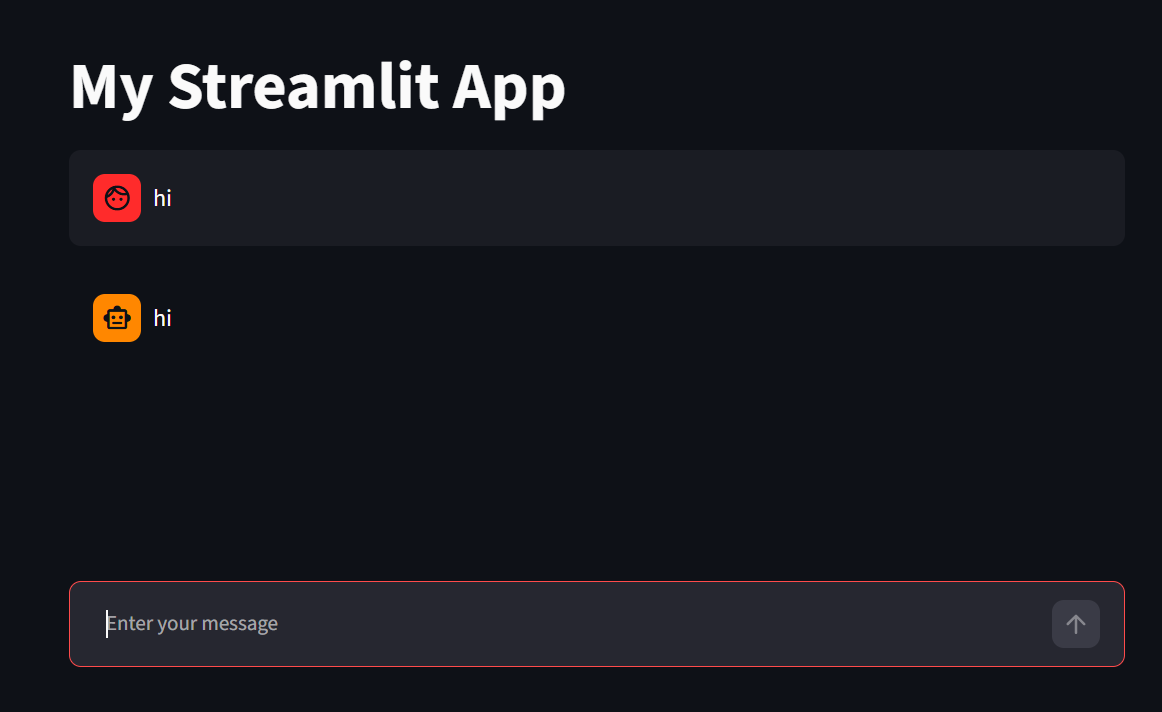

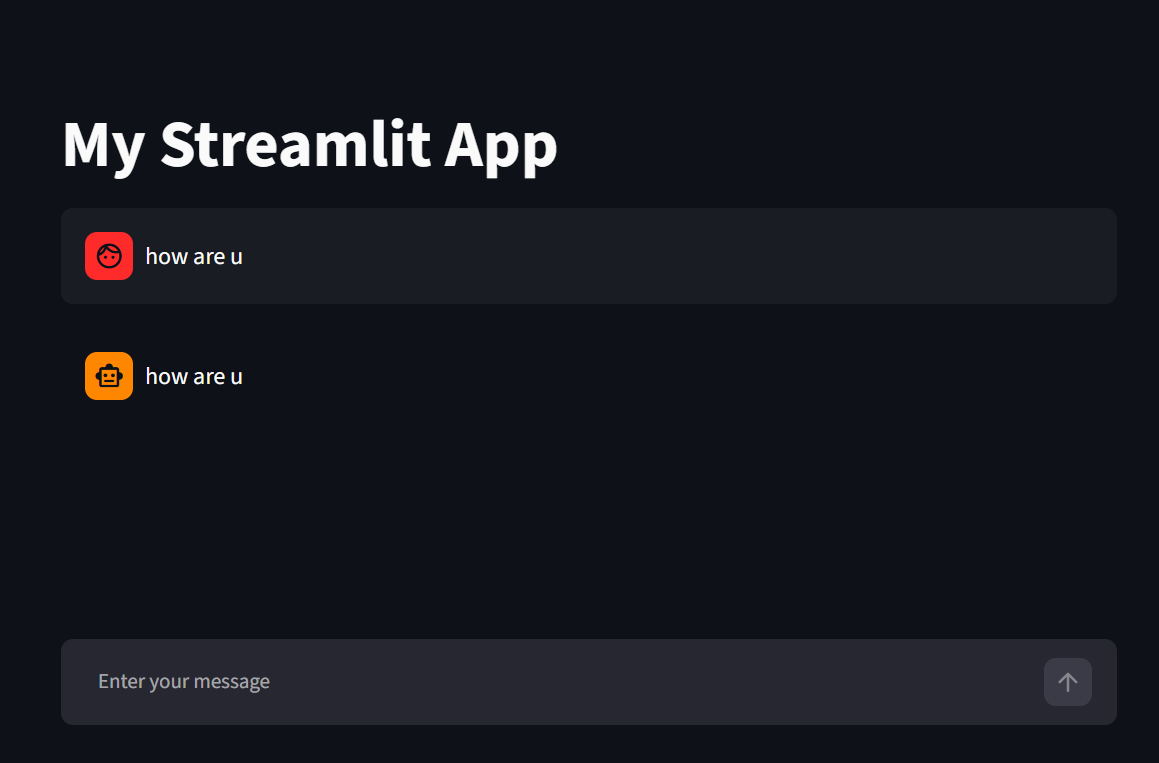